# Target Hit Analysis

Runs `analyze_target_hit.py` across all six combinations (All / S&P / Nasdaq
x Hit / Miss) in one place, instead of six separate terminal calls.

Edit `OUTPUT_FOLDER` below to point at your `parse_sessions.py` output
folder, then run all cells.

In [12]:

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import analyze_target_hit as ath
from pathlib import Path

OUTPUT_FOLDER = Path(r"C:\Git\CandleStateSessionAnalysis\data\MACDTarget\output")

sessions, positions = ath.load_tables(OUTPUT_FOLDER)
print(f"{len(sessions)} sessions, {len(positions)} positions loaded")

85 sessions, 262 positions loaded


## All (S&P + Nasdaq combined)

How you actually trade -- no index filtering.

In [13]:
profile = ath.profile_target_hit_days(sessions, positions, None, target_hit=True)
ath.print_summary(profile, target_hit=True)

54 target-hit session(s)

One direction only: 36 (67%)
Flipped direction:  18 (33%)

Position count distribution:
PositionCount
1     2
2    34
3    10
4     6
5     1
6     1

Direction combination counts:
                          Count      TotalPL       AvgPL
Directions                                              
Long                         21  6635.099945  315.957140
Short                        15  5387.106658  359.140444
Short, Long                  10  3489.776448  348.977645
Long, Short, Long             3   970.798566  323.599522
Long, Short                   3  1047.493797  349.164599
Short, Long, Short            1   284.579090  284.579090
Short, Long, Short, Long      1   299.419388  299.419388

                                    SourceFile  AccountName  PositionCount                          Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-03__2026-07-14_0756.json Test Account              3                  SDS, UPRO, TQQQ              Shor

In [14]:
profile = ath.profile_target_hit_days(sessions, positions, None, target_hit=False)
ath.print_summary(profile, target_hit=False)

31 target-missed session(s)

One direction only: 1 (3%)
Flipped direction:  30 (97%)

Position count distribution:
PositionCount
2     1
3    10
4     7
5    11
6     2

Direction combination counts:
                          Count      TotalPL       AvgPL
Directions                                              
Long, Short                  11  -266.336058  -24.212369
Short, Long, Short            6 -2666.852775 -444.475462
Short, Long, Short, Long      5  -474.378203  -94.875641
Short, Long                   4  -638.326134 -159.581534
Long, Short, Long             3 -1361.316653 -453.772218
Long, Short, Long, Short      1  -259.526649 -259.526649
Short                         1  -287.295032 -287.295032

                                    SourceFile  AccountName  PositionCount                         Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-02__2026-07-14_0756.json Test Account              4            QID, SDS, TQQQ, UPRO              Short, Long  

## S&P only (UPRO/SDS)

In [15]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["S"], target_hit=True)
ath.print_summary(profile, target_hit=True)

52 target-hit session(s)

One direction only: 35 (67%)
Flipped direction:  17 (33%)

Position count distribution:
PositionCount
1    35
2    13
3     3
4     1

Direction combination counts:
                          Count      TotalPL       AvgPL
Directions                                              
Long                         20  2233.715235  111.685762
Short                        15  2281.528653  152.101910
Short, Long                  10  1470.096710  147.009671
Long, Short                   3   208.376559   69.458853
Long, Short, Long             3   169.884492   56.628164
Short, Long, Short, Long      1    81.778402   81.778402

                                    SourceFile  AccountName  PositionCount              Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-03__2026-07-14_0756.json Test Account              2            SDS, UPRO              Short, Long     True  341.343284
Session_File__2026-03-05__2026-07-14_0756.json Test Account         

In [16]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["S"], target_hit=False)
ath.print_summary(profile, target_hit=False)

31 target-missed session(s)

One direction only: 5 (16%)
Flipped direction:  26 (84%)

Position count distribution:
PositionCount
1     5
2    17
3     7
4     2

Direction combination counts:
                          Count     TotalPL       AvgPL
Directions                                             
Long, Short                  12  872.371450   72.697621
Short                         5 -123.854190  -24.770838
Short, Long                   5    4.193415    0.838683
Short, Long, Short            4 -261.649875  -65.412469
Long, Short, Long             3 -612.539056 -204.179685
Short, Long, Short, Long      2 -139.171591  -69.585796

                                    SourceFile  AccountName  PositionCount              Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-02__2026-07-14_0756.json Test Account              2            SDS, UPRO              Short, Long     True  -54.335055
Session_File__2026-03-04__2026-07-14_0756.json Test Account              3

## Nasdaq only (TQQQ/QID)

In [17]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["N"], target_hit=True)
ath.print_summary(profile, target_hit=True)

54 target-hit session(s)

One direction only: 49 (91%)
Flipped direction:  5 (9%)

Position count distribution:
PositionCount
1    49
2     3
3     2

Direction combination counts:
                    Count      TotalPL       AvgPL
Directions                                        
Long                   34  7606.929926  223.733233
Short                  15  3507.650800  233.843387
Short, Long             2   175.402452   87.701226
Long, Short             1   172.881110  172.881110
Long, Short, Long       1   323.523257  323.523257
Short, Long, Short      1  -117.493705 -117.493705

                                    SourceFile  AccountName  PositionCount         Symbols         Directions  Flipped  RealizedPL
Session_File__2026-03-03__2026-07-14_0756.json Test Account              1            TQQQ               Long    False  261.994230
Session_File__2026-03-05__2026-07-14_0756.json Test Account              1             QID              Short    False  250.664544
Session_File__202

In [18]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["N"], target_hit=False)
ath.print_summary(profile, target_hit=False)

31 target-missed session(s)

One direction only: 10 (32%)
Flipped direction:  21 (68%)

Position count distribution:
PositionCount
1     9
2    17
3     4
4     1

Direction combination counts:
                          Count      TotalPL       AvgPL
Directions                                              
Short, Long                  10 -1609.768681 -160.976868
Long                          7  -456.370586  -65.195798
Long, Short                   6 -1641.684130 -273.614022
Short                         3  -231.795842  -77.265281
Long, Short, Long             2  -737.268710 -368.634355
Short, Long, Short            2  -799.270675 -399.635337
Short, Long, Short, Long      1  -217.223033 -217.223033

                                    SourceFile  AccountName  PositionCount              Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-02__2026-07-14_0756.json Test Account              2            QID, TQQQ              Short, Long     True  -32.403473
Session_

## Visualization (optional)

Uses `visualize_target_hit.py`'s combined hit/miss profile -- same data as
above, plotted instead of printed. Delete this section if you just want
the six text summaries above.

Saved C:\Git\CandleStateSessionAnalysis\data\MACDTarget\output\target_hit_visualization.png


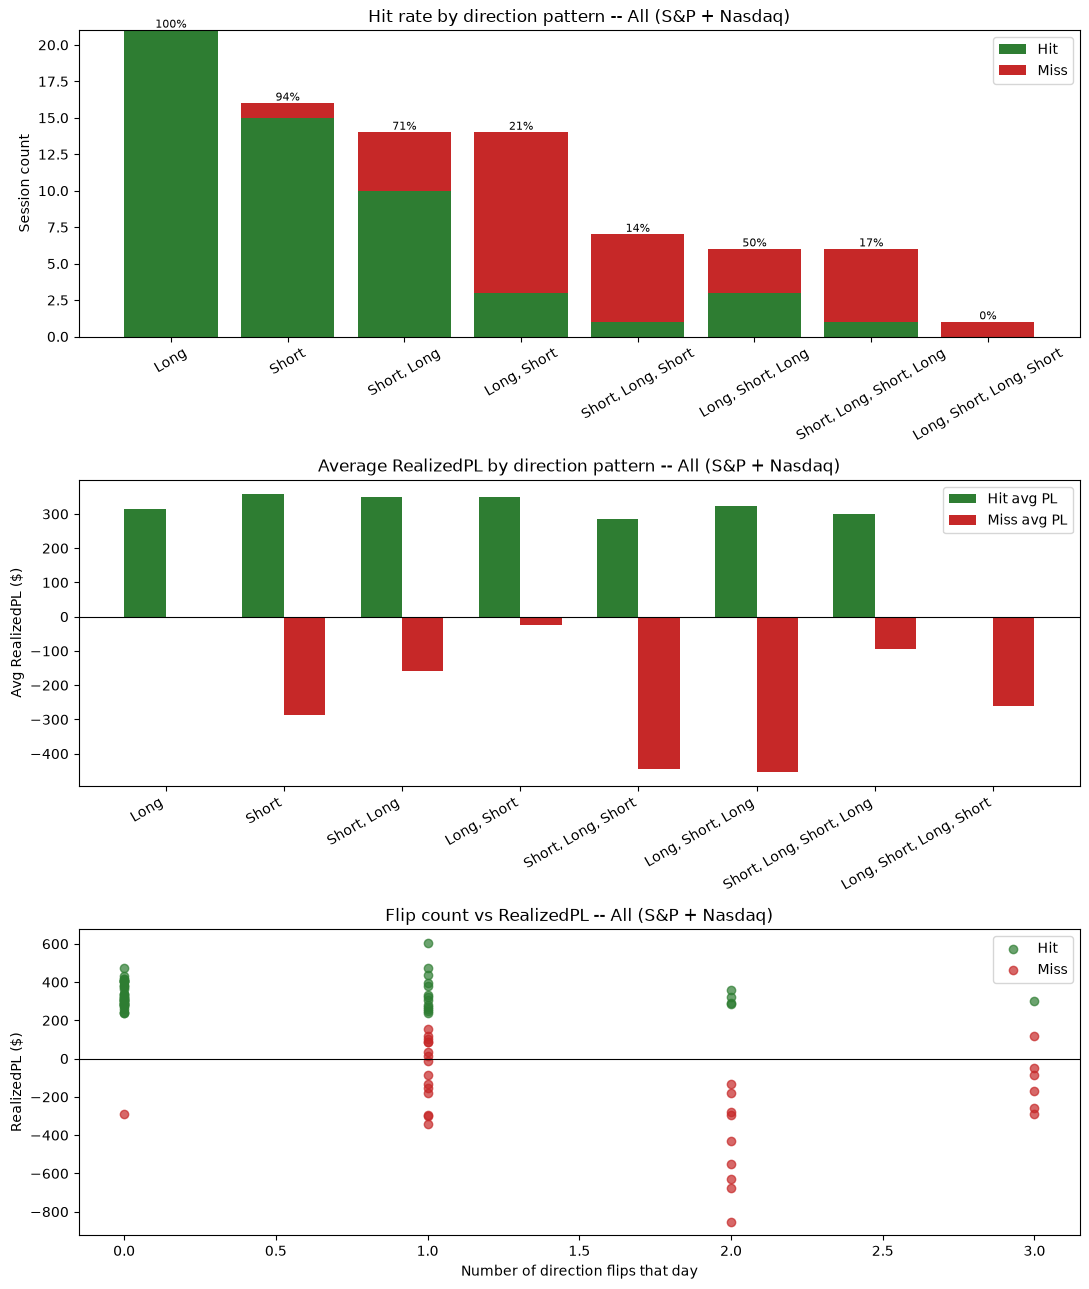

In [19]:
%matplotlib inline
import visualize_target_hit as vth

full_profile = vth.build_full_profile(sessions, positions, None)
vth.plot_profile(full_profile, "All (S&P + Nasdaq)", OUTPUT_FOLDER / "target_hit_visualization.png")